In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Make plots look clean
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
import os

files = [
    '../data/train_FD001.txt',
    '../data/test_FD001.txt',
    '../data/RUL_FD001.txt',
]

for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) // 1024
        print(f"✅ Found: {f}  ({size} KB)")
    else:
        print(f"❌ Missing: {f} — copy it into the /data folder")

✅ Found: ../data/train_FD001.txt  (3432 KB)
✅ Found: ../data/test_FD001.txt  (2176 KB)
✅ Found: ../data/RUL_FD001.txt  (0 KB)


In [4]:
# Column names: engine id, cycle, 3 op settings, 21 sensors
cols = ['engine_id', 'cycle', 'op_1', 'op_2', 'op_3'] + \
       [f'sensor_{i}' for i in range(1, 22)]

def load_data(path):
    df = pd.read_csv(path, sep=r'\s+', header=None,
                     names=cols, engine='python')
    df.dropna(axis=1, how='all', inplace=True)
    return df

train_df = load_data('../data/train_FD001.txt')
test_df  = load_data('../data/test_FD001.txt')
rul_df   = pd.read_csv('../data/RUL_FD001.txt', sep=r'\s+',
                        header=None, names=['RUL'], engine='python')
rul_df.dropna(axis=1, how='all', inplace=True)

print(f"Train : {train_df.shape[0]:,} rows × {train_df.shape[1]} cols")
print(f"Test  : {test_df.shape[0]:,} rows × {test_df.shape[1]} cols")
print(f"RUL   : {rul_df.shape[0]} engines")
train_df.head()

Train : 20,631 rows × 26 cols
Test  : 13,096 rows × 26 cols
RUL   : 100 engines


,engine_id,cycle,op_1,op_2,op_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
# Sensors with very low std dev carry no signal — drop them
sensor_cols = [c for c in train_df.columns if 'sensor' in c]
stds = train_df[sensor_cols].std()
drop_cols = stds[stds < 0.1].index.tolist()

print(f"Dropping {len(drop_cols)} near-constant sensors: {drop_cols}")

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols,  inplace=True)

sensor_cols = [c for c in train_df.columns if 'sensor' in c]
print(f"Remaining sensors ({len(sensor_cols)}): {sensor_cols}")

Dropping 10 near-constant sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19']
Remaining sensors (11): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']


In [6]:
# RUL = max_cycle_for_engine − current_cycle
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

train_df = train_df.merge(max_cycles, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)

# Cap RUL at 125 — piecewise linear target (standard practice)
RUL_CAP = 125
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)

print(f"RUL range : {train_df['RUL'].min()} → {train_df['RUL'].max()}")
print(f"Mean RUL  : {train_df['RUL'].mean():.1f} cycles")
train_df[['engine_id', 'cycle', 'RUL']].head(10)

RUL range : 0 → 125
Mean RUL  : 86.8 cycles


,engine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


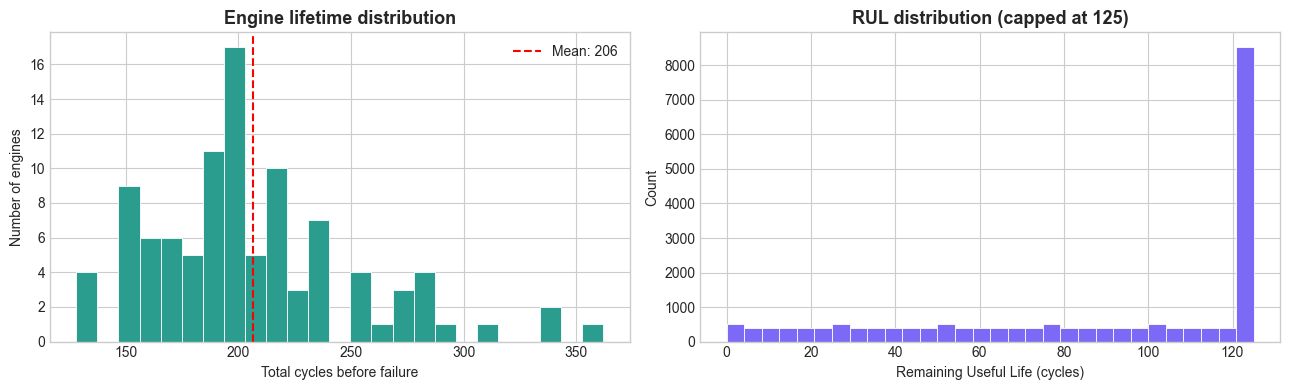

Avg engine life: 206 cycles | Min: 128 | Max: 362


In [7]:
engine_life = train_df.groupby('engine_id')['cycle'].max()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(engine_life, bins=25, color='#2a9d8f', edgecolor='white', linewidth=0.6)
axes[0].set_title('Engine lifetime distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total cycles before failure')
axes[0].set_ylabel('Number of engines')
axes[0].axvline(engine_life.mean(), color='red', linestyle='--',
              label=f'Mean: {engine_life.mean():.0f}')
axes[0].legend()

# RUL distribution
axes[1].hist(train_df['RUL'], bins=30, color='#7c6af7', edgecolor='white', linewidth=0.6)
axes[1].set_title('RUL distribution (capped at 125)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Remaining Useful Life (cycles)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/plot1_lifetimes.png', dpi=120)
plt.show()
print(f"Avg engine life: {engine_life.mean():.0f} cycles | Min: {engine_life.min()} | Max: {engine_life.max()}")

Available sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']


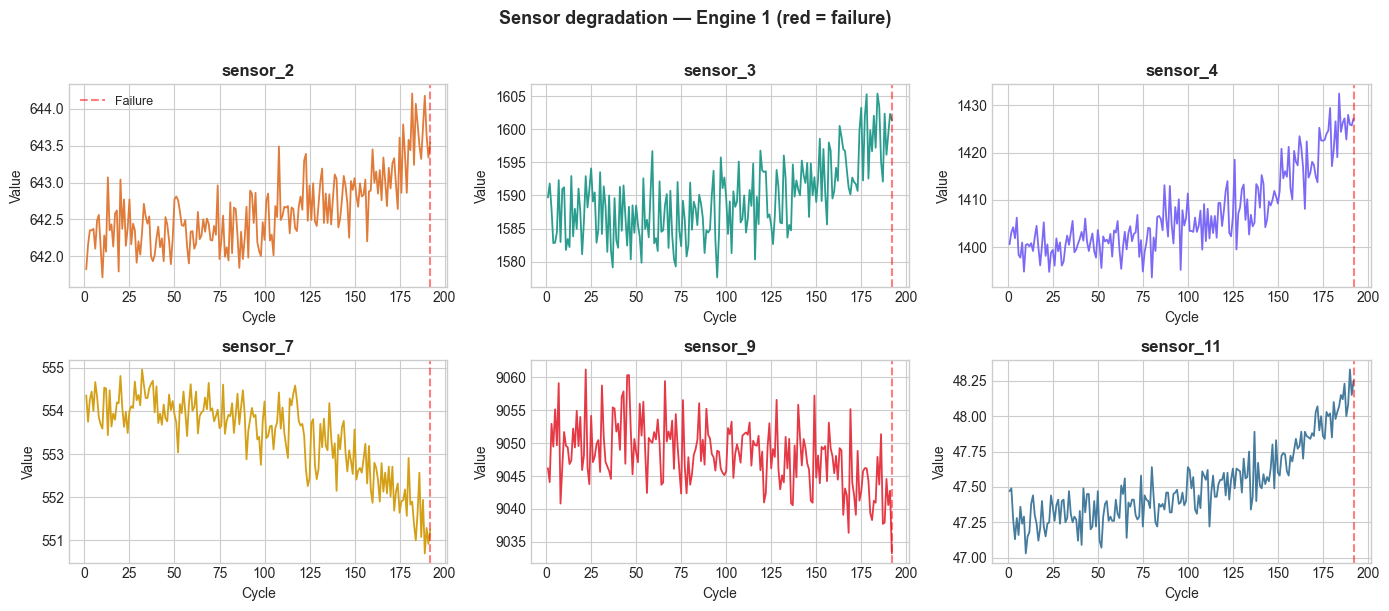

In [9]:
# Auto-pick 6 sensors that still exist after dropping near-constants
available_sensors = [c for c in train_df.columns if 'sensor' in c]
print("Available sensors:", available_sensors)

# Pick 6 from what's actually in the dataframe
plot_sensors = available_sensors[:6]

eng1 = train_df[train_df['engine_id'] == 1]
colors = ['#e07b39', '#2a9d8f', '#7c6af7', '#d4a017', '#e63946', '#457b9d']

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for i, (sensor, color) in enumerate(zip(plot_sensors, colors)):
    axes[i].plot(eng1['cycle'], eng1[sensor], color=color, linewidth=1.3)
    axes[i].axvline(eng1['cycle'].max(), color='red',
                    linestyle='--', alpha=0.5, label='Failure')
    axes[i].set_title(sensor, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cycle', fontsize=10)
    axes[i].set_ylabel('Value', fontsize=10)

axes[0].legend(fontsize=9)
plt.suptitle('Sensor degradation — Engine 1 (red = failure)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/plot2_degradation.png', dpi=120)
plt.show()

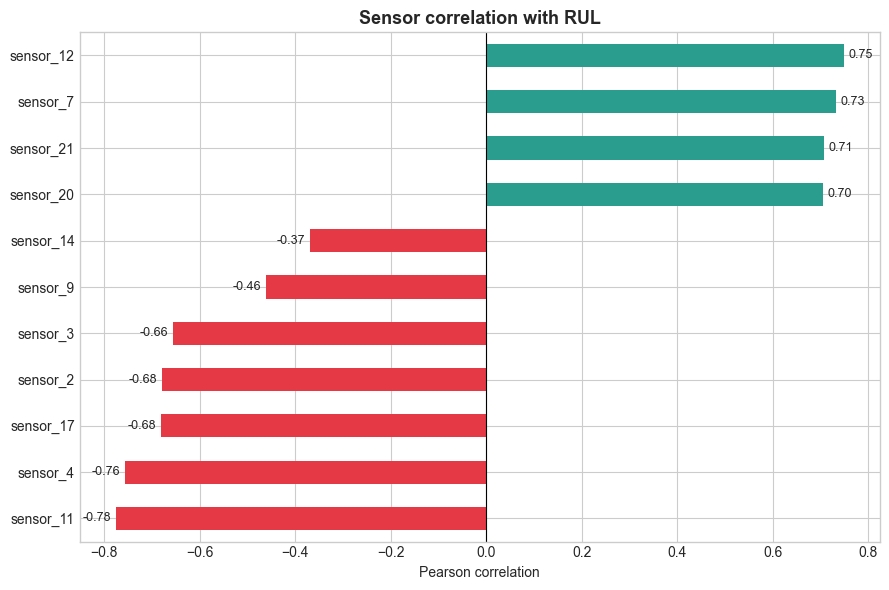


🎯 Top 8 sensors selected for LSTM: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_21', 'sensor_20', 'sensor_17', 'sensor_2']


In [10]:
corr = train_df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['#e63946' if v < 0 else '#2a9d8f' for v in corr]
corr.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Sensor correlation with RUL', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson correlation')
# Annotate values
for i, v in enumerate(corr):
    ax.text(v + (0.01 if v >= 0 else -0.01), i,
           f'{v:.2f}', va='center', fontsize=9,
           ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.savefig('../data/plot3_correlation.png', dpi=120)
plt.show()

# Pick top 8 by absolute correlation for modelling
top_sensors = corr.abs().sort_values(ascending=False).head(8).index.tolist()
print(f"\n🎯 Top 8 sensors selected for LSTM: {top_sensors}")

In [11]:
feature_cols = top_sensors

scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

print("After normalisation:")
print(train_df[feature_cols].describe().loc[['min', 'max', 'mean']].round(3))

# Save scaler — we'll need it in the dashboard later
import pickle
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ Scaler saved to models/scaler.pkl")

After normalisation:
      sensor_11  sensor_4  sensor_12  sensor_7  sensor_21  sensor_20  \
min       0.000      0.00      0.000     0.000      0.000      0.000   
max       1.000      1.00      1.000     1.000      1.000      1.000   
mean      0.411      0.45      0.581     0.566      0.546      0.524   

      sensor_17  sensor_2  
min       0.000     0.000  
max       1.000     1.000  
mean      0.434     0.443  

✅ Scaler saved to models/scaler.pkl


In [12]:
WINDOW = 30  # look back 30 cycles at a time

def create_sequences(df, feature_cols, window=30):
    """
    Sliding window over each engine's sensor history.
    X: (n_samples, window, n_features)
    y: RUL at the end of each window
    """
    X, y = [], []
    for eng_id in df['engine_id'].unique():
        eng = df[df['engine_id'] == eng_id].reset_index(drop=True)
        vals = eng[feature_cols].values
        rul  = eng['RUL'].values
        for i in range(len(eng) - window):
            X.append(vals[i : i + window])
            y.append(rul[i + window - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_df, feature_cols, WINDOW)

print(f"X_train : {X_train.shape}  → (samples, window, features)")
print(f"y_train : {y_train.shape}  → RUL for each sample")

# Save processed data — no need to rerun next time
np.save('../data/X_train.npy', X_train)
np.save('../data/y_train.npy', y_train)
print(f"\n✅ Phase 1 complete! Data saved to /data")
print(f"   Ready to build the LSTM in 02_lstm.ipynb")

X_train : (17631, 30, 8)  → (samples, window, features)
y_train : (17631,)  → RUL for each sample

✅ Phase 1 complete! Data saved to /data
   Ready to build the LSTM in 02_lstm.ipynb
